In [1]:
!pip install pandas scikit-learn

In [2]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

In [3]:
emails = ["Win money now",
    "Click here urgently",
    "Meeting at 5 PM",
    "Project update attached",
    "Claim your free reward",
    "Team meeting tomorrow"]

labels = ["phishing",
    "phishing",
    "safe",
    "safe",
    "phishing",
    "safe"]

In [4]:
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(emails)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,
    labels,
    test_size=0.2,
    random_state=42)

In [6]:
model = MultinomialNB()
model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [7]:
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy * 100)

Accuracy: 0.0


In [8]:
test_email = ["Click here to claim free money"]
test_data = vectorizer.transform(test_email)
prediction = model.predict(test_data)
print("Prediction:", prediction[0])

Prediction: phishing


In [9]:
data = pd.read_csv("dataset.csv")
data.head()

,text,label
0,Win money now,phishing
1,Click here urgently,phishing
2,Claim your free reward,phishing
3,Update your bank details,phishing
4,You have won a lottery,phishing


In [12]:
X = data["text"]
y = data["label"]

In [13]:
vectorizer = CountVectorizer()
X_vectorized = vectorizer.fit_transform(X)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
model = MultinomialNB()
model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [16]:
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy * 100)

Accuracy: 100.0


In [17]:
test_email = ["Click here to verify your account"]
test_data = vectorizer.transform(test_email)
prediction = model.predict(test_data)
print("Email:", test_email[0])
print("Result:", "Phishing " if prediction[0] == "phishing" else "Safe ")

Email: Click here to verify your account
Result: Phishing 


In [18]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
cm = confusion_matrix(y_test, predictions)
print(cm)

[[3 0]
 [0 1]]


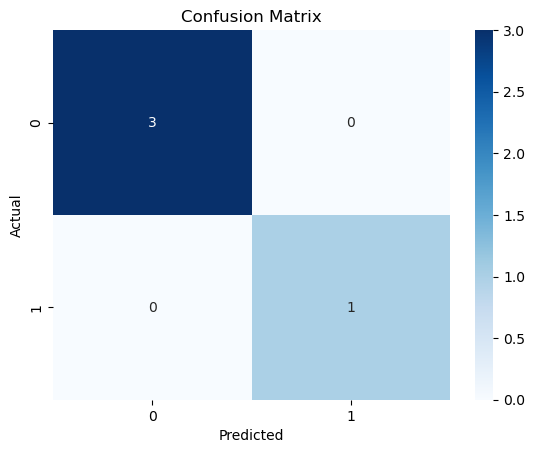

In [20]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()